In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [197]:
bad_encoding = ['2021-01', '2021-02', '2021-04', '2021-05', '2021-06', '2021-07', '2021-08', '2021-09', '2021-10', '2021-11', '2021-12']

bad_semicolons = ['2022-01', '2022-02', '2022-03']

In [198]:
dfs = []
for filename in bad_encoding:
    filename = f"{filename}.csv"
    dfs.append(pd.read_csv(f"./data/{filename}", sep=';', encoding='ISO-8859-1'))

power1 = pd.concat(dfs, ignore_index=True)

In [199]:
power1['P+'] = power1['P+'].str.replace(',', '.').astype(float)

In [200]:
dfs = []
for filename in bad_semicolons:
    filename = f"{filename}.csv"
    dfs.append(pd.read_csv(f"./data/{filename}", sep=';'))

power2 = pd.concat(dfs, ignore_index=True)

In [201]:
power2['P+'] = power2['P+'].str.replace(',', '.').astype(float)

In [202]:
dfs = []
for year, month in zip(range(2022, 2025), range(4, 13)) :
    filename = f"{year}-{month:02d}.csv"
    dfs.append(pd.read_csv(f"./data/{filename}"))

dfs.append(power1)
dfs.append(power2)

power = pd.concat(dfs, ignore_index=True)

In [203]:
power.PL_T = power.PL_T.str.replace('.000', '')

power.PL_T = pd.to_datetime(power.PL_T)

In [204]:
power = power[power.GR_NAME.str.contains('Vilniaus miesto')]

In [205]:
power.sort_values(by='PL_T', ascending=True)

,GR_NAME,PL_T,P+,OBJ_COUNT
107733,Vilniaus miesto Vartotojai,2021-01-01 00:00:00,1132.9429,3380
107734,Vilniaus miesto Vartotojai,2021-01-01 01:00:00,1055.2680,3380
107735,Vilniaus miesto Vartotojai,2021-01-01 02:00:00,973.4354,3380
107736,Vilniaus miesto Vartotojai,2021-01-01 03:00:00,876.9959,3380
107737,Vilniaus miesto Vartotojai,2021-01-01 04:00:00,802.8210,3301
...,...,...,...,...
77445,Vilniaus miesto Vartotojai,2024-06-30 19:00:00,20.7987,13
77446,Vilniaus miesto Vartotojai,2024-06-30 20:00:00,20.7083,13
77447,Vilniaus miesto Vartotojai,2024-06-30 21:00:00,20.4645,13
77448,Vilniaus miesto Vartotojai,2024-06-30 22:00:00,17.2012,13


In [206]:
power = power.reset_index(drop=True)

In [207]:
power = power['P+']

<Axes: >

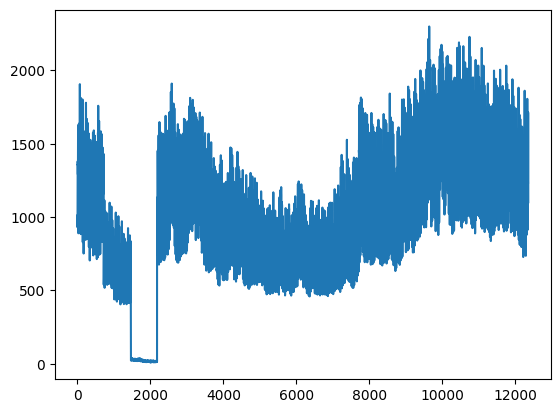

In [212]:
power.plot()